In [1]:
import pandas as pd

pd.set_option('display.max_column', 20)

In [2]:
df = pd.read_excel('https://storage.googleapis.com/dqlab-dataset/cth_churn_analysis_train.xlsx')

df.drop('ID_Customer', axis=1, inplace=True)

In [3]:
df['Jenis_kelamin']= df['Jenis_kelamin'].map(
   lambda value: 1 if value == 'Perempuan' else 0)
 
df['using_reward']= df['using_reward'].map(
   lambda value: 1 if value == 'Yes' else 0)

df['pembayaran']= df['pembayaran'].map(
    lambda value: 2 if value == 'Credit' 
    else 1 if value == 'Bank Transfer' 
    else 0)

df['Subscribe_brochure']= df['Subscribe_brochure'].map(
    lambda value: 0 if value == 'No'  else 1)

df['churn'] = df['churn'].map(
    lambda value: 1 if value == 'Yes' else 0)

In [4]:
y = df.pop('churn').to_numpy()

X = df.to_numpy()

In [5]:
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier
 
#library yang dapat kita gunakan untuk menghitung nilai precision recall trade-off
from sklearn.metrics import precision_recall_curve

In [6]:
kf = KFold(n_splits=10, shuffle=True, random_state=12)
kf.get_n_splits(X)

10

In [7]:
#variabel untuk menyimpan label ground-truth atau label referensi dari setiap iterasi
y_true_all = []
 
#variabel untuk menyimpan label hasil prediksi dari setiap iterasi
y_pred_all = []
 
for train_index, test_index in kf.split(X):
	X_train, X_test = X[train_index], X[test_index]
	y_train, y_test = y[train_index], y[test_index]
	
	model = DecisionTreeClassifier(random_state=12)
	model.fit(X_train, y_train)
	
	y_pred = model.predict_proba(X_test)
	
	#menambahkan label ground_truth ke dalam variabel
	y_true_all.extend(y_test)
	#menambahkan label prediksi ke dalam variabel
	y_pred_all.extend(y_pred[:,1])

In [8]:
precisions, recalls, thresholds = precision_recall_curve(y_true_all, y_pred_all)
	
#mengiterasi setiap nilai threshold, precision dan recall yang dihasilkan oleh fungsi precision_recall_curve
for i in range(0,len(thresholds)):
	print('Saat nilai threshold: %.2f maka nilai Precision: %.2f dan Recall: %.2f' % (thresholds[i], precisions[i], recalls[i]))

Saat nilai threshold: 0.00 maka nilai Precision: 0.53 dan Recall: 1.00
Saat nilai threshold: 0.33 maka nilai Precision: 0.52 dan Recall: 0.56
Saat nilai threshold: 0.50 maka nilai Precision: 0.52 dan Recall: 0.56
Saat nilai threshold: 0.67 maka nilai Precision: 0.53 dan Recall: 0.49
Saat nilai threshold: 1.00 maka nilai Precision: 0.53 dan Recall: 0.48


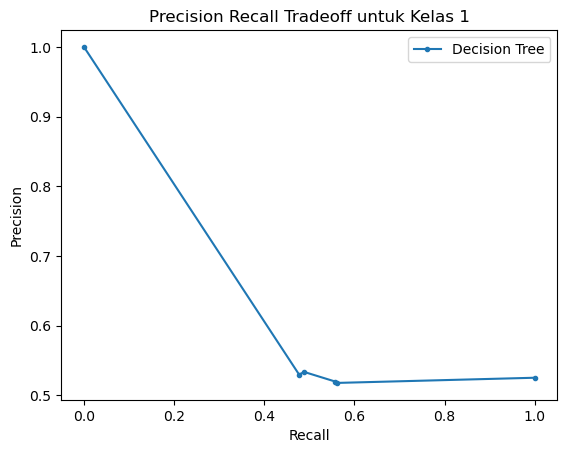

In [9]:
import matplotlib.pyplot as plt

plt.plot(recalls, precisions, marker='.', label='Decision Tree')

#axis labels
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title("Precision Recall Tradeoff untuk Kelas 1")

#show the legend
plt.legend()

#show the plot
plt.show()